In [1]:
import json
import math
import os
import gc
import itertools
from functools import partial
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

from PIL import Image
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, backend as K
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dropout, Flatten, Dense, GlobalAveragePooling2D, Average,
    Input, Concatenate, GlobalMaxPooling2D, BatchNormalization
)
from tensorflow.keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.applications import (
    DenseNet121,
    DenseNet169,
    DenseNet201
)
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn import metrics

%matplotlib inline

2026-06-06 13:35:12.723853: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780752912.960119      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780752913.027583      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780752913.556272      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780752913.556371      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780752913.556374      22 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf

# Disable XLA
tf.config.optimizer.set_jit(False)

In [3]:
def Dataset_loader_recursive(DIR, RESIZE):
    IMG = []
    
    for root, _, files in os.walk(DIR):
        for file in files:
            PATH = os.path.join(root, file)
            _, ftype = os.path.splitext(PATH)
            
            if ftype.lower() in [".jpg", ".jpeg", ".png"]:
                try:
                    img = np.asarray(Image.open(PATH).convert("RGB"))
                    img = cv2.resize(img, (RESIZE, RESIZE))
                    IMG.append(img)
                except:
                    continue
    
    return np.array(IMG)
DIR = "/kaggle/input/datasets/tueoban/aisslab-breast-cancer-sub-datasets/AISSLab Sub-datasets/Raw Sub-datasets/AISSLab-v5"

benign_bi_rads_2 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 2"), RESIZE=224)
benign_bi_rads_3 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 3"), RESIZE=224)

malignant_bi_rads_4 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 4"), RESIZE=224)
malignant_bi_rads_5 = Dataset_loader_recursive(os.path.join(DIR, "BI-RADS 5"), RESIZE=224)

#normal = Dataset_loader_recursive(os.path.join(DIR, "Normal/JPG/"), RESIZE=224)

In [4]:
print("Total images loaded:", len(benign_bi_rads_2))
print("Shape:", benign_bi_rads_2.shape)

print("Total images loaded:", len(benign_bi_rads_3))
print("Shape:", benign_bi_rads_3.shape)

print("Total images loaded:", len(malignant_bi_rads_4))
print("Shape:", malignant_bi_rads_4.shape)

print("Total images loaded:", len(malignant_bi_rads_5))
print("Shape:", malignant_bi_rads_5.shape)

Total images loaded: 18
Shape: (18, 224, 224, 3)
Total images loaded: 48
Shape: (48, 224, 224, 3)
Total images loaded: 54
Shape: (54, 224, 224, 3)
Total images loaded: 46
Shape: (46, 224, 224, 3)


In [5]:
#normal_label = np.full(len(normal),0)
benign_bi_rads_2_label = np.full(len(benign_bi_rads_2), 0)
benign_bi_rads_3_label = np.full(len(benign_bi_rads_3),1)
malignant_bi_rads_4_label = np.full(len(malignant_bi_rads_4),2)
malignant_bi_rads_5_label = np.full(len(malignant_bi_rads_5),3)

In [6]:
X = np.concatenate((benign_bi_rads_2, benign_bi_rads_3, malignant_bi_rads_4, malignant_bi_rads_5), axis = 0)
Y = np.concatenate((benign_bi_rads_2_label, benign_bi_rads_3_label, malignant_bi_rads_4_label, malignant_bi_rads_5_label), axis = 0)

# Shuffle train data
s = np.arange(X.shape[0])
np.random.shuffle(s)
X = X[s]
Y = Y[s]

# DENSENET PREPROCESSING
X = preprocess_input(
    X.astype("float32")
)
x_train, x_test, y_train, y_test = train_test_split(
    X,Y,
    test_size=0.2,
    stratify=Y,
    random_state=11
)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=11,
    stratify=y_train
)

print("\nFinal Shapes:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)


Final Shapes:
x_train: (105, 224, 224, 3)
y_train: (105,)
x_val: (27, 224, 224, 3)
y_val: (27,)
x_test: (34, 224, 224, 3)
y_test: (34,)


In [8]:
from imblearn.over_sampling import RandomOverSampler
from tensorflow.keras.utils import to_categorical
from collections import Counter
import numpy as np

# Convert one-hot -> labels if needed
if len(y_train.shape) > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Check original distribution
print("Original class distribution:")
print(Counter(y_train_labels))

# Flatten image data temporarily
nsamples, h, w, c = x_train.shape

x_train_flat = x_train.reshape(
    (nsamples, h * w * c)
)

target = 1200

sampling_strategy = {
    0: target,
    1: target,
    2: target,
    3: target
}

# Apply Oversampling
ros = RandomOverSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

x_train, y_train = ros.fit_resample(
    x_train_flat,
    y_train_labels
)

# Restore image shape
x_train = x_train.reshape(
    (-1, h, w, c)
)

# One-hot Encode Labels
y_train = to_categorical(
    y_train,
    num_classes=4
)

# Validation labels
if len(y_val.shape) == 1:
    y_val = to_categorical(y_val, num_classes=4)

# Test labels
if len(y_test.shape) == 1:
    y_test = to_categorical(y_test, num_classes=4)

# Final Distribution
print("\nBalanced class distribution:")
print(Counter(np.argmax(y_train, axis=1)))

Original class distribution:
Counter({np.int64(2): 34, np.int64(3): 30, np.int64(1): 30, np.int64(0): 11})

Balanced class distribution:
Counter({np.int64(2): 1200, np.int64(3): 1200, np.int64(0): 1200, np.int64(1): 1200})


In [9]:
BATCH_SIZE = 32

# Using original generator
train_generator = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam

def build_model(model_name):

    inputs = Input(shape=(224,224,3))

    if model_name=="DenseNet121":
        base_model=DenseNet121(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    elif model_name=="DenseNet169":
        base_model=DenseNet169(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    elif model_name=="DenseNet201":
        base_model=DenseNet201(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )

    for layer in base_model.layers:
        layer.trainable=False

    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    x=BatchNormalization()(x)
    x=Dropout(0.5)(x)
    x=Dense(256,activation="relu")(x)
    x=Dropout(0.4)(x)
    outputs=Dense(4,activation="softmax")(x)
    
    # FINAL MODEL
    model=Model(inputs,outputs)

     # COMPILE
    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model,base_model

In [11]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

def get_callbacks(model_name):

    checkpoint = ModelCheckpoint(
        f"/kaggle/working/{model_name}_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    earlystop = EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        mode='max',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    return [checkpoint, earlystop, reduce_lr]

In [12]:
def train_model(model, model_name):
    history = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=20,
        callbacks=get_callbacks(model_name)
    )
    return history

In [13]:
def fine_tune_model(model, base_model, model_name):

    # Unfreeze last 30 layers
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    # Recompile
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_fine = model.fit(
        train_generator.flow(
            x_train,
            y_train,
            batch_size=32
        ),
        steps_per_epoch=x_train.shape[0] // 32,
        validation_data=(x_val, y_val),
        epochs=30,
        callbacks=get_callbacks(model_name)
    )

    return history_fine

In [14]:
def plot_history(history, model_name):

    f, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
    f.suptitle(f'{model_name} Training History',fontsize=12)
    f.subplots_adjust(top=0.85,wspace=0.3)
    epoch_list = range(1,len(history.history['accuracy'])+1)
    ax1.plot(epoch_list,history.history['accuracy'],label='Train Accuracy')
    ax1.plot(epoch_list,history.history['val_accuracy'],label='Validation Accuracy')
    ax1.grid()
    ax1.set_ylabel('Accuracy Value')
    ax1.set_xlabel('Epoch')
    ax1.set_title('Accuracy')
    ax1.legend(loc="best")
    ax2.plot(epoch_list,history.history['loss'],label='Train Loss')
    ax2.plot(epoch_list,history.history['val_loss'],label='Validation Loss')
    ax2.grid()
    ax2.set_ylabel('Loss Value')
    ax2.set_xlabel('Epoch')
    ax2.set_title('Loss')
    ax2.legend(loc="best")
    plt.show()

I0000 00:00:1780752972.125462      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780752972.131655      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1780752991.612691      68 service.cc:152] XLA service 0x7cb858002130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780752991.612745      68 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780752991.612751      68 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780752995.454438      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/150 ━━━━━━━━━━━━━━━━━━━━ 1:20:09 32s/step - accuracy: 0.1562 - loss: 3.2518

I0000 00:00:1780753009.285838      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.2766 - loss: 2.1688
Epoch 1: val_accuracy improved from None to 0.29630, saving model to /kaggle/working/DenseNet121_best.keras

Epoch 1: finished saving model to /kaggle/working/DenseNet121_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 103s 476ms/step - accuracy: 0.3227 - loss: 1.8941 - val_accuracy: 0.2963 - val_loss: 1.4801 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.4386 - loss: 1.4640
Epoch 2: val_accuracy improved from 0.29630 to 0.40741, saving model to /kaggle/working/DenseNet121_best.keras

Epoch 2: finished saving model to /kaggle/working/DenseNet121_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 56s 370ms/step - accuracy: 0.4538 - loss: 1.3890 - val_accuracy: 0.4074 - val_loss: 1.3522 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.5250 - loss: 1.2233
Epoch 3: val_accuracy did not improve from 0.40741
150/150 ━━━━━━━━━━━━━━━━━━━━ 52s

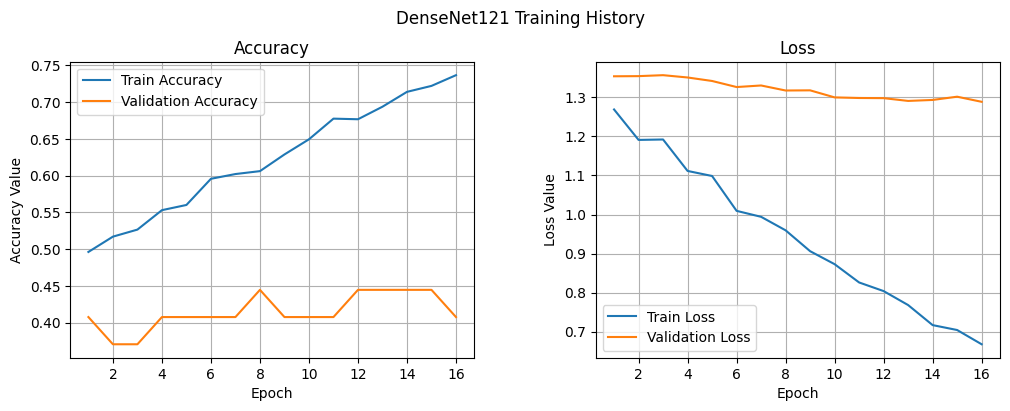

In [15]:
# BUILD MODEL
model_densenet121, base_densenet121 = build_model("DenseNet121")

# TRAIN
history_densenet121 = train_model(model_densenet121,"DenseNet121")

# FINE TUNE
history_densenet121_fine = fine_tune_model(model_densenet121,base_densenet121,"DenseNet121")

# SHOW FINAL GRAPH
plot_history(history_densenet121_fine,"DenseNet121")

In [16]:
# PREDICTION
pred_densenet121 = model_densenet121.predict(x_test)

# Predicted class
y_pred_densenet121 = np.argmax(pred_densenet121,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet121 = accuracy_score(y_true,y_pred_densenet121)
print("DenseNet121 Accuracy:",acc_densenet121)

2/2 ━━━━━━━━━━━━━━━━━━━━ 27s 15s/step
DenseNet121 Accuracy: 0.4117647058823529


In [17]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()

gc.collect()

0

51877672/51877672 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.3016 - loss: 1.9346
Epoch 1: val_accuracy improved from None to 0.22222, saving model to /kaggle/working/DenseNet169_best.keras

Epoch 1: finished saving model to /kaggle/working/DenseNet169_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 115s 513ms/step - accuracy: 0.3554 - loss: 1.7123 - val_accuracy: 0.2222 - val_loss: 1.3373 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.4696 - loss: 1.3145
Epoch 2: val_accuracy improved from 0.22222 to 0.37037, saving model to /kaggle/working/DenseNet169_best.keras

Epoch 2: finished saving model to /kaggle/working/DenseNet169_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 367ms/step - accuracy: 0.4906 - loss: 1.2620 - val_accuracy: 0.3704 - val_loss: 1.2666 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.5510 - loss: 1.0955
Epoch 3: val_accuracy

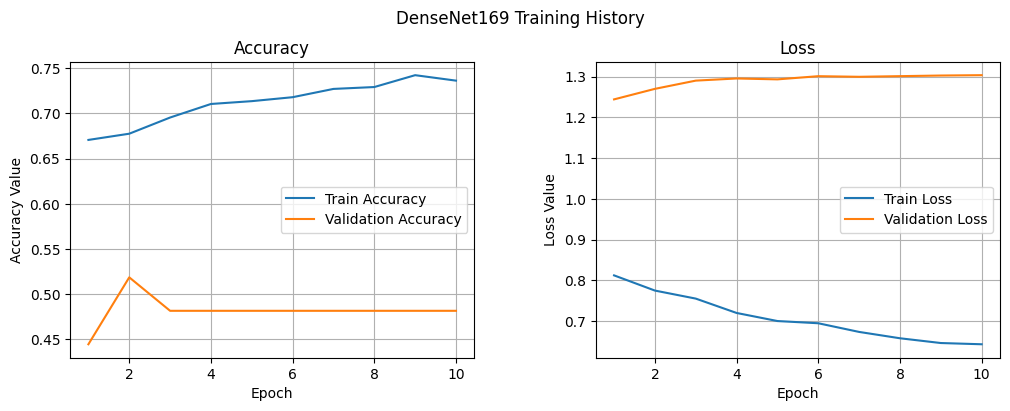

In [18]:
# BUILD MODEL
model_densenet169, base_densenet169 = build_model("DenseNet169")

# TRAIN
history_densenet169 = train_model(model_densenet169,"DenseNet169")

# FINE TUNE
history_densenet169_fine = fine_tune_model(model_densenet169,base_densenet169,"DenseNet169")

# SHOW FINAL GRAPH
plot_history(history_densenet169_fine,"DenseNet169")

In [19]:
# PREDICTION
pred_densenet169 = model_densenet169.predict(x_test)

# Predicted class
y_pred_densenet169 = np.argmax(pred_densenet169,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet169 = accuracy_score(y_true,y_pred_densenet169)

print("DenseNet169 Accuracy:",acc_densenet169)

2/2 ━━━━━━━━━━━━━━━━━━━━ 39s 20s/step
DenseNet169 Accuracy: 0.5


In [20]:
import gc
import tensorflow as tf

tf.keras.backend.clear_session()

gc.collect()

0

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.3341 - loss: 1.7745
Epoch 1: val_accuracy improved from None to 0.33333, saving model to /kaggle/working/DenseNet201_best.keras

Epoch 1: finished saving model to /kaggle/working/DenseNet201_best.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 129s 553ms/step - accuracy: 0.3915 - loss: 1.5661 - val_accuracy: 0.3333 - val_loss: 1.4389 - learning_rate: 1.0000e-04
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.5208 - loss: 1.2006
Epoch 2: val_accuracy did not improve from 0.33333
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 364ms/step - accuracy: 0.5450 - loss: 1.1377 - val_accuracy: 0.3333 - val_loss: 1.3818 - learning_rate: 1.0000e-04
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.5978 - loss: 1.0063
Epoch 3: val_accuracy did not improve from 0.33333
150/150 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.6121 - loss: 0.9498 - val_accuracy: 0.3333 - v

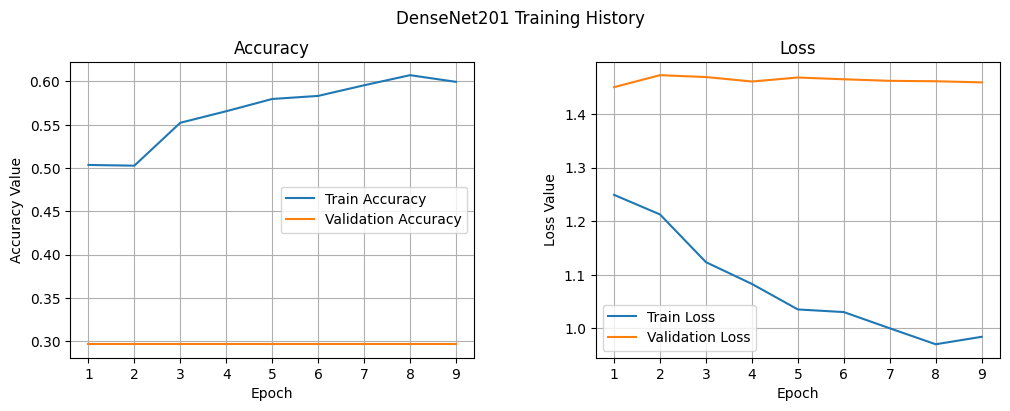

In [21]:
# BUILD MODEL
model_densenet201, base_densenet201 = build_model("DenseNet201")

# TRAIN
history_densenet201 = train_model(model_densenet201,"DenseNet201")

# FINE TUNE
history_densenet201_fine = fine_tune_model(model_densenet201,base_densenet201,"DenseNet201")

# SHOW FINAL GRAPH
plot_history(history_densenet201_fine,"DenseNet201")

In [22]:
# PREDICTION
pred_densenet201 = model_densenet201.predict(x_test)

# Predicted class
y_pred_densenet201 = np.argmax(pred_densenet201,axis=1)

# True class
y_true = np.argmax(y_test,axis=1)

# Accuracy
acc_densenet201 = accuracy_score(y_true,y_pred_densenet201)

print("DenseNet201 Accuracy:",acc_densenet201)

1/2 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7cb69b214860> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 24s/step
DenseNet201 Accuracy: 0.3235294117647059


In [23]:
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef,mean_absolute_error,mean_squared_error,cohen_kappa_score)
import itertools
def evaluate_model(model, model_name):

    print(f"\n{'='*50}")
    print(f"{model_name} EVALUATION")
    print(f"{'='*50}")

    # Prediction
    pred = model.predict(x_test)
    y_pred = np.argmax(pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true,y_pred,average='weighted')
    recall = recall_score(y_true,y_pred,average='weighted')

    f1 = f1_score(y_true,y_pred,average='weighted')
    mcc = matthews_corrcoef(y_true, y_pred )
    kappa = cohen_kappa_score(y_true,y_pred )

    # Classification Report
    print("\nClassification Report:\n")

    target_names = ['Benign (BI-RADS 2)','Benign (BI-RADS 3)','Malign (BI-RADS 4)','Malign (BI-RADS 5)']
    print(classification_report(y_true,y_pred,target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n")
    print(cm)
    # Plot CM
    plt.figure(figsize=(6,6))
    plt.imshow(cm, cmap=plt.cm.Blues)
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks,target_names,rotation=45)
    plt.yticks(tick_marks,target_names)
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,
            format(cm[i, j], 'd'),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()
    # Final Metrics
    print("\nAdditional Metrics:\n")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Precision      : {precision:.4f}")
    print(f"Recall         : {recall:.4f}")
    print(f"F1-score       : {f1:.4f}")
    print(f"MCC            : {mcc:.4f}")
    print(f"Cohen Kappa    : {kappa:.4f}")
    return accuracy


DenseNet121 EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 756ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.33      0.25      0.29         4
Benign (BI-RADS 3)       0.50      0.50      0.50        10
Malign (BI-RADS 4)       0.38      0.27      0.32        11
Malign (BI-RADS 5)       0.38      0.56      0.45         9

          accuracy                           0.41        34
         macro avg       0.40      0.39      0.39        34
      weighted avg       0.41      0.41      0.40        34


Confusion Matrix:

[[1 0 2 1]
 [0 5 2 3]
 [0 4 3 4]
 [2 1 1 5]]


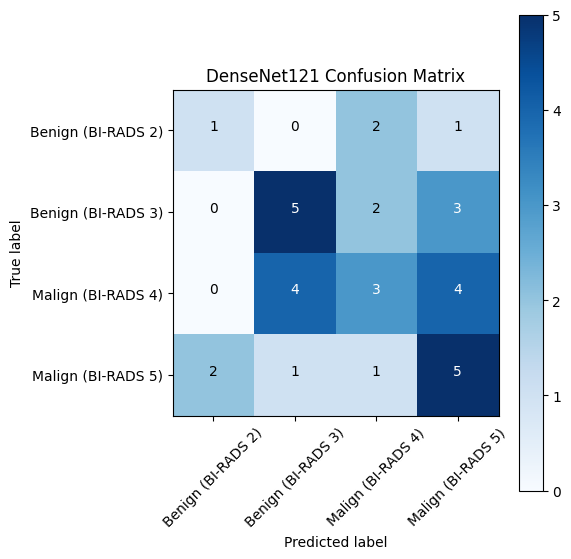


Additional Metrics:

Accuracy       : 0.4118
Precision      : 0.4094
Recall         : 0.4118
F1-score       : 0.4032
MCC            : 0.1925
Cohen Kappa    : 0.1895


In [24]:
acc_densenet121 = evaluate_model(
    model_densenet121,
    "DenseNet121"
)


DenseNet169 EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.50      0.50      0.50         4
Benign (BI-RADS 3)       0.50      0.50      0.50        10
Malign (BI-RADS 4)       0.44      0.36      0.40        11
Malign (BI-RADS 5)       0.55      0.67      0.60         9

          accuracy                           0.50        34
         macro avg       0.50      0.51      0.50        34
      weighted avg       0.49      0.50      0.49        34


Confusion Matrix:

[[2 1 1 0]
 [0 5 3 2]
 [0 4 4 3]
 [2 0 1 6]]


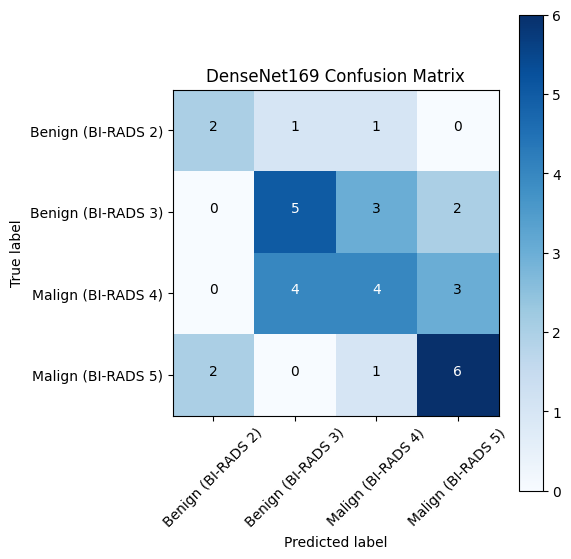


Additional Metrics:

Accuracy       : 0.5000
Precision      : 0.4941
Recall         : 0.5000
F1-score       : 0.4941
MCC            : 0.3150
Cohen Kappa    : 0.3135


In [25]:
acc_densenet169 = evaluate_model(
    model_densenet169,
    "DenseNet169"
)


DenseNet201 EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step

Classification Report:

                    precision    recall  f1-score   support

Benign (BI-RADS 2)       0.33      0.25      0.29         4
Benign (BI-RADS 3)       0.14      0.10      0.12        10
Malign (BI-RADS 4)       0.38      0.27      0.32        11
Malign (BI-RADS 5)       0.38      0.67      0.48         9

          accuracy                           0.32        34
         macro avg       0.31      0.32      0.30        34
      weighted avg       0.30      0.32      0.30        34


Confusion Matrix:

[[1 1 1 1]
 [2 1 3 4]
 [0 3 3 5]
 [0 2 1 6]]


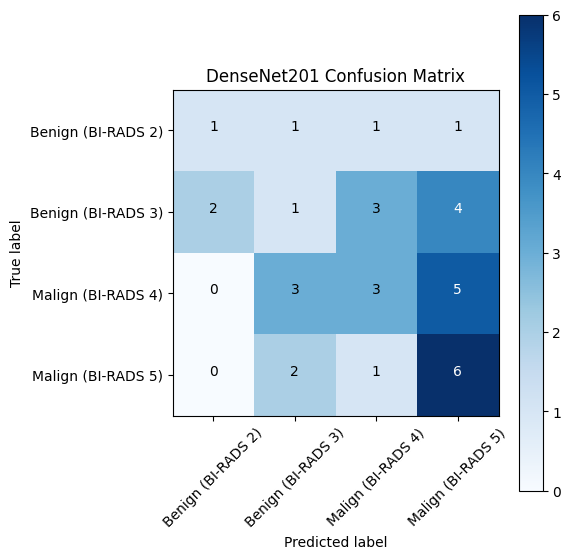


Additional Metrics:

Accuracy       : 0.3235
Precision      : 0.3018
Recall         : 0.3235
F1-score       : 0.2974
MCC            : 0.0743
Cohen Kappa    : 0.0713


In [26]:
acc_densenet201 = evaluate_model(
    model_densenet201,
    "DenseNet201"
)

In [27]:
print("\nFINAL COMPARISON")
print("="*45)

print(f"DenseNet121 Accuracy : {acc_densenet121:.4f}")
print(f"DenseNet169 Accuracy : {acc_densenet169:.4f}")
print(f"DenseNet201 Accuracy : {acc_densenet201:.4f}")

best_acc = max(acc_densenet121,acc_densenet169,acc_densenet201)

if best_acc == acc_densenet121:
    print("\nBest Model : DenseNet121")

elif best_acc == acc_densenet169:
    print("\nBest Model : DenseNet169")

else:
    print("\nBest Model : DenseNet201")


FINAL COMPARISON
DenseNet121 Accuracy : 0.4118
DenseNet169 Accuracy : 0.5000
DenseNet201 Accuracy : 0.3235

Best Model : DenseNet169
